# C: Transport og fluidmekanikk

Vi studerer fluidmekanikken. Vi skal også ta en omvei innom trafikkflyt, både fordi det er interessant, men også på pedagogisk grunnlag.

Ligningene som modeller de to er ganske like! Vi begynner med en oversikt over fluidmekanikk, og hva det har med de vanligste PDE-typer å gjøre. Da studerer vi trafikk, og så gass.

## Innføring i Fluidmekanikk

Tilstand til et stoff (som vann, luft osv) i likevekt beskrives at to termodynamiske variabler, for eksempler tetthet $\rho$ og trykket $p$.

Erfaringen sier at fluider er sjelden i likevekt. Det håndteres stort sett sånt:

1. Tetthet $\rho(\vec{x},t)$ og $p(\vec{x},t)$ varierer i både tid og rom
2. Forflytting beskrives av et hastighetsfelt $\vec{u}(\vec{x},t)$, også avhengig av tid og rom.

Generelt finner vi $\rho, p, \vec{u}$ ved å løse partielle differensialligninger. Men først, litt om hva $\vec{u}$ egentlig sier.

## 1. Hastighetsfelt (kinematikk)

Hastighetsfeltet $\vec{u}(\vec{x},t)$ beskriver endring av posisjon til en partikkel som befinner seg ved punkt $\vec{x}$ på tid $t$. Med andre ord, en partikkel som befinner seg i $\vec{x}_0$ ved tid $t=0$ følger en ordinær differensialligning:

$$
\frac{d}{dt}\vec{x}(t) = \vec{u}\big(\vec{x}(t),t\big), \quad \vec{x}(0) = \vec{x}_0
$$

### Eksempel: partikkel i et gitt felt

La

$$
\vec{u}(\vec{x},t) = A\vec{x}, \quad A = \begin{pmatrix}
0 & 1 \\
-1 & 0
\end{pmatrix}
$$

Da følger en partikkel $\vec{x}(t)$ som begynner ved $\vec{x}(0) = (1,0)$

$$
\vec{x}(t) = \begin{pmatrix}
\cos(t) \\
\sin(t)
\end{pmatrix}
$$



## Oppgave 1

En partikkel $\vec{x}(t)$ beveger seg fra $\vec{x}(0) = (1,0)$ i det tidsavhengige feltet

$$
\vec{u}(\vec{x},t) = A(t)\vec{x}, \quad A(t) = \begin{pmatrix}
\cos(t) & \cos(t)+\sin(t) \\
-\sin(t) & 0
\end{pmatrix}
$$

Bruk Eulers metode til å spore posisjon til partikkelen over tid.

## Løsning

Koden kjøres under

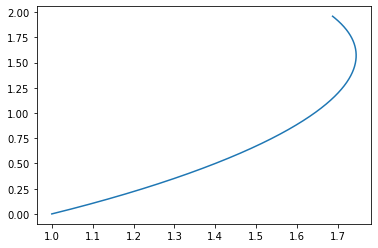

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def A(t):
    return np.array([[np.cos(t),-np.sin(t)],[np.cos(t)+np.sin(t),0]])

def euler(f,x0,a,b,N):
    t = np.linspace(a,b,N)
    x = np.zeros((N,x0.size))
    x[0,:] = x0
    for i in np.arange(N-1):
        x[i+1,:] = x[i,:] + (t[i+1]-t[i])*(f(x[i],t[i]))
    return x,t

def f(x,t):
    return A(t) @ x

u0 = np.array([1,0])

u, t = euler(f, u0, 0, 1, 1000)

fig, ax = plt.subplots()

ax.plot(u[:,0],u[:,1])

## Oppgave 2: Utledning av trafikkligninga

I stedet for å følge hver enkelt bils posisjon skal vi beskrive trafikkflyten langs en 1-dimensjonal vei ved å bruke *biltettheten* $u(x,t)$ i posisjon $x$ ved tiden $t$ for å karakterisere hvordan trafikken utvikler seg. Vi vil også anta at alle sjåfører har samme kjøreadferd. Vi noterer oss at *enheten* til biltettheten $u$ er antall pr. meter.

I prinsippet  er det klart at biltettheten langs veien er $0$ mellom to biler, akkurat som massetettheten til en gass er $0$ i tomrommet mellom gassmolekyler. Allikevel bruker fysikerne massetettheten til en gass $\rho(x,y,z,t)$ som en kontinuerlig (og gjerne deriverbar) funksjon av sine variabler $(x,y,z,t)$ i klassisk fluiddynamikk. Altså er det klart $\rho(x,y,z,t)$ ikke betegner massetettheten til gassen på en *mikroskopisk skala*, men betegner et slags gjennomsnitt av massetettheten på en større skala.

### a) Biler og molekyler

Anta vi har en gass bestående av en type molekyler. 

1. Foreslå en formel for "gjennomsnittlig massetetthet i posisjon $(x,y,z)$", $\rho(x,y,z,t)$, der antall molekyler i en kule med radius $R>0$ og sentrum i $(x,y,z)$ inngår i formelen. I tillegg vil formelen inneholde massen $m$ til hvert enkelt molekyl.

I vår trafikkmodell antar vi at biltettheten $u(x,t)$ langs den 1-dimesjonale veien er definert på tilsvarende måte der vi har middlet tettheten av biler over intervallet $[-R+x,R+x]$ for å definere $u(x,t)$. Det er nokså tilfeldig hva $R$ velges som, kanskje $10$ billengder gir en passende middling for å definere $u(x,t)$.


2. Reflekter over hva som er konsekvensen for definisjonen av $u(x,t)$ ved å velge $R$ "liten" (si en billengde) eller velge $R$ "stor" (si $50$ billengder).

Vår grunnleggende antagelse i  trafikkmodellen vi skal se på er at hastigheten til bilene i posisjon $x$ ved tiden $t$ er en funksjon alene av biltettheten $u(x,t)$. Vi antar også at det er en konstant $u_m$ som angir maksimal biltetthet og at $v_m$ er den maksimale hastigheten bilene kan kjøre i.

### b) Hastighet og fluks

1. Vi lar $v(u)$ betegne hastigheten bilene kjører i der det er biltetthet $u$.  Bør $v(u)$ være en voksende eller avtagende funksjon av $u\in [0,u_m]$?. Hva er rimelige verdier for $v(0)$ og $v(u_m)$? Bør $v(u)$ være kontinuerlig (besvares med sunn fornuft)? 

Vi skal nå se på strømmen eller *fluksen* av biler i et punkt $x$ langs veien ved tiden $t$. Vi definerer fluksen av biler, $J(x,t)$, til å være antall biler som passer et punkt $x$ pr. tidsenhet. Altså har $J$ enhet antall pr. sekund).

2. Prøv å forklare med ord hvorfor fluksen er gitt ved

$$
    J(x,t)=J(u(x,t))=u(x,t)v(u(x,t)),
$$

der $v(u)$ er hastigheten bilene kjører i når det er biltetthet $u$.

### c) Utleding av ligningen

Antall biler som passerer punktet $x$ på veien i tidsintervallet $[t,t+\Delta t]$ er altså (tilnærmet lik)

$$
    J(x,t)\Delta t
$$

Videre er antall biler som befinner seg i intervallet $[x,x+\Delta x ]$ ved tiden $t$ gitt ved (tilnærmet) 

$$
    u(x,t)\Delta x
$$

Nå skal vi sette opp et regnskap for bilene som er helt analogt med det de fleste av oss har et forhold til. Vi vet at penger inn på konto minus penger ut av konto over et tidsrom er lik netto endring av saldoen.

Analogt, er antall biler i intervallet $[x,x+\Delta x]$ ved tiden $t+\Delta t$ minus antall biler i $[x,x+\Delta x]$ ved tiden $t$ lik netto endring i antall av biler i $[x,x+\Delta x]$ i tidsrommet $t$ til $t+\Delta t$.

Analogt med bankkonto må dette matche antall biler som kjører inn i intervallet $[x,x+\Delta x]$ minus antall biler som kjører ut av $[x,x+\Delta x]$ i tidsrommet $t$ til $t+\Delta t$.


1. Uttrykk dette regnskapet matematisk, og vis at det fører til ligninga

$$
\frac{u(x,t+\Delta t)-u(x,t)}{\Delta t}=-\frac{J(x+\Delta x, t)-J(x,t)}{\Delta x}.
$$

2. Sjekk at venstre og høyre side av ligningen begge har samme fysiske enhet.


Som vanlig i denne type modellering ser vi på ligning over når $\Delta x\rightarrow 0$ og $\Delta t\rightarrow 0$.

3. Vis at ligningen over blir

$$
\frac{\partial u(x,t)}{\partial t}=-\frac{\partial J(x,t)}{\partial x}
$$

når $\Delta x \rightarrow 0$ og $\Delta t \rightarrow 0$.

Legg merke til at når vi deriverer en fysisk størrelse med hensyn på en fysisk variabel (sånn som $\frac{\partial J}{\partial x}$) endres enheten til $J$ ved at vi må dividere med enheten til $x$. Dvs. enheten til  $\frac{\partial J}{\partial x}$ er biler pr. tid pr. lengde.

## Løsning

### a)

1. Vi har $\rho(x,y,z,t) = n(x,y,z,t)\frac{m}{V}$, hvor $V=\frac{4}{3}\pi R^3$, og $n(x,y,z,t)$ er antall molekyler i kula i tid $t$

2. En definisjon $u(x,t) \propto n(x,t)$ (eventuelle konstanter er uvesentlige) hvor $n(x,t)$ er antall biler i $[-R+x,R+x]$ er det vi får. En stor $R$ vil gi en jevnere men mindre nøyaktig modell.

### b)

1. Vi venter at $v(u)$ er avtagende og kontinuerlig. For en veg vil $v(0)$ være fartsgrensa (kall det $v_m$) og $v(u_m)$ være null.

2. Alle biler i intervallet $[x-vt, x]$ kommer til å passere $x$ etter tid $t$, hvis vi tar $t=1$ er det altså antall biler i et intervall med størrelse $v$, som tilsvarer $v$ intervaller av enhetsstørrelse, altså $v\times u$.

### c)

1. Den første setning oversettes til

$$
u(x,t+\Delta t)\Delta x - u(x,t)\Delta x
$$

som må være lik

$$
J(x,t)\Delta t - J(x+\Delta x, t)\Delta t
$$

Vi setter dem sammen for å få ligningen.

2. Enhetene blir antall biler per tidsenhet per lengdeenhet

3. Den kommer av definisjonen til de deriverte

## Oppgave 3: Løsninger av ligningen


La oss anta at hastigheten følger

$$
v(u)=v_m(1-(\frac{u}{u_m})^p),
$$
der $p>0$ er en konstant parameter. 

slik at trafikkligningen blir

$$
u_t + f(u)_x = 0, \quad f(u) = u\cdot v(u)
$$


### a)

Biler står foran et rødt lys. Vi har nemlig

$$
u(0,x) = \left\{
\begin{array}[cc]
& 1 \quad & x<0 \\
0 \quad & x\geq 0
\end{array}
\right.
$$

Løs ligningen for $p=1$ med karakteristikker.

### b)

Posisjon $y(t)$ til en tilfeldig bil som står ved $x=-1$ er gitt av

$$
\frac{dy}{dt} = v\big(u(y,t)\big), \quad y(0)=-1.
$$

Finn $y(t)$ og tegn det under. Ser det realistisk ut?

### c)

Bruk Lax-Friedrichs metode til å løse ligningen for andre verdier av $p$. Hvordan påvirker $p$ trafikkflyt? Hva tror du er mest realistisk? Vil en modell med bare formel-1 sjåfører ha større eller mindere verdi for $p$ enn en modell med vanlige hverdagssjåfører?

## Løsning

Vi skriver ligningen i en ikke-konservativ form:

$$
u_t + f_u u_x = 0,
$$

hvor 

$$
f_u = v_m \left( 1- \left(\frac{(p+1)u}{u_m}\right)^p\right) 
$$

1. Da er karakteristikkene gitt av (gitt $p\neq 1$)

$$
\frac{dx}{dt} = f_u = \left\{
\begin{array}[cc]
& 1- \frac{p+1}{u_m} \quad & x(0)<0 \\
1 \quad & x(0) > 0
\end{array}
\right.
$$

**Må legge ved en tegning**

Vi har også at
$$
u(x,t) = \left\{
\begin{array}[cc]
& 1 \quad & x <  v_m \left(1- \frac{p+1}{u_m}\right) t\\
0 \quad & x > t
\end{array}
\right.
$$

Det er en lineær interpolasjon av 1 og 0 for $v_m \left(1- \frac{p+1}{u_m}\right) t \leq x \leq t$, altså

$$
u(x,t) = -\frac{x - v_m \left(1- \frac{p+1}{u_m}\right) t}{t - v_m \left(1- \frac{p+1}{u_m}\right) t },
\quad v_m \left(1- \frac{p+1}{u_m}\right) t \leq x \leq t
$$


2. Fart er også

$$
u(x,t) = \left\{
\begin{array}[cc]
& v_m\left( 1 - \frac{1}{u_m^p}\right) \quad & x <  v_m \left(1- \frac{p+1}{u_m}\right) t\\
v_m\left(1+\left(\frac{x - v_m \left(1- \frac{p+1}{u_m}\right) t}{u_m \left(t - v_m \left(1- \frac{p+1}{u_m}\right) t \right)}\right)^p \right) \quad & v_m \left(1- \frac{p+1}{u_m}\right) t \leq x \leq t \\
v_m \quad & x > t
\end{array}
\right.
$$

Vi viser hvordan det ser ut for $u_m=1, v_m=1, p=1$, hvor

$$
u(x,t) = \left\{
\begin{array}[cc]
&0 \quad &x < -t \\
1 + \frac{x-t}{2t} \quad & -t\leq x\leq t \\
1 \quad &x > t
\end{array}
\right.
$$

3. Se under, prøv forskjellige verdier.

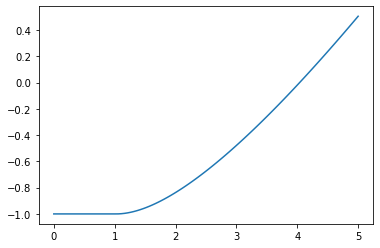

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,t):
    if x<-t:
        return 0
    elif x>=t:
        return 1
    else:
        return 1 + (x-t)/(2*t)
    
f = np.vectorize(f)

def euler(f,x0,a,b,N):
    t = np.linspace(a,b,N)
    x = np.zeros((N,x0.size))
    x[0,:] = x0
    for i in np.arange(N-1):
        x[i+1,:] = x[i,:] + (t[i+1]-t[i])*(f(x[i],t[i]))
    return x,t

x = np.linspace(-5,5,100)

u0 = np.array([-1.0])

u, t = euler(f, u0, 0, 5, 100)

fig, ax = plt.subplots()

ax.plot(t,u)

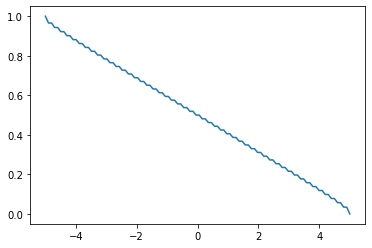

In [3]:

import matplotlib.animation as animation

def lf(fluks, fa, fb, x0, h, k, t):
    n = x0.size
    x1 = np.zeros(n)
    for i in np.arange(1,n-1):
        x1[i] = (x0[i-1] + x0[i+1])/2 - (k/h)*(fluks(x0[i+1])-fluks(x0[i-1]))
    x1[0] = fa(t)
    x1[-1] = fb(t)
    return x1

vm = 1
um = 1
p = 1

def v(u):
    return vm*(1-(u/um)**p)

def f(u):
    return u*v(u)

def fa(x):
    return 1

def fb(x):
    return 0

T = 10
n = 200

a = -5
b = 5
m = 100

t = np.linspace(0,T,n)
x = np.linspace(a,b,m)

k = t[1]-t[0]
h = x[1]-x[0]

u = np.zeros((n,m))

u[0,:] = (1-np.sign(x))/2

for i in np.arange(1,n):
    u[i,:] = lf(f, fa, fb, u[i-1,:],h,k,t[i])
    
fig, ax = plt.subplots()

line, = ax.plot(x, u[0,:])

def animate(i):
    line.set_ydata(u[i,:])
    return line,

ani = animation.FuncAnimation(fig, animate, interval=20, blit=True, save_count=50)

from IPython.display import HTML
HTML(ani.to_jshtml())

## 3. Dynamikk (hvordan finne hastigheten)

Ligningen for $\vec{u}$ er mer komplisert (du får en million dollar om du løser den... https://no.wikipedia.org/wiki/Millenniumprisproblem), og mer et tema for matematikk 3. En liten smakbit på hvordan det funker i en dimensjon:

Grovt sett, kommer det fra en bevaringslov for *impuls*, $\rho u$, og i en dimensjon tar formen

$$
\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} - \nu\frac{\partial^2 u}{\partial x^2} = -\frac{1}{\rho}\frac{\partial p}{\partial x}
$$

Hvis $\rho,p$ er kjent får vi en ligning som kombinerer både varmeligning og en (ikke-lineær) bevaringslov. Generelt er det konkurrende krefter:

1. Transport av impuls: $u\frac{\partial u}{\partial x}$ 
2. Dissipasjon fra viskositet: $-\nu\frac{\partial^2 u}{\partial x^2}$

Om 2 dominerer 1 kan vi faktisk bruke varmeligningen til å finne flyte: det heter *Stokes flow*.

Om 1 dominere 2 kan vi se bort fra viskositet og bruke bare bevaringsloven, da har vi *Eulers ligninger*.

Det er imidlertidig ikke alltid enkelt i dette tilfelle: det kan hende at selv om $\nu$ er veldig liten, at det kan fortsett ikke ignoreres i nærheten av en rand (ellers får vi ikke oppfylt randbetingelsene). Det kan vi se bort fra her.

## Oppgave 4: 

La oss anta at vi har konstant trykk $p$, slik at leddet på høyre siden over forsvinner, og vi får den såkalte (viskose) Burgers ligning:

$$
\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} - \nu\frac{\partial^2 u}{\partial x^2} = 0
$$

La oss betrakte problemet hvor
$$
u(0,x) = \left\{
\begin{array}[cc]
& 2\quad & x<0 \\
0 \quad & x\geq 0
\end{array}
\right.
$$

### a)

Vis at ligningen løses av

$$
u(x,t) = \frac{2}{1+\exp\left(\frac{x-t}{\nu}\right)}
$$

### b)

Plott løsningen $u$ for forskjellige verdier av $\nu$. Hva skjer når $\nu\rightarrow 0$?

### c)

Sett opp en numerisk metode for ligningen basert på sentrale differanser i rom og forlengs Euler i tid. Bruk altså

$$
u_t(t_n,x_m) \approx \frac{u^{n+1}_m - u^n_m}{k}, \quad
u_x(t_n,x_m) \approx \frac{u^n_{m+1}-u^n_{m-1}}{2h}, \quad
u_{xx}(t_n,x_m) \approx \frac{u^n_{m+1}-2u^n_m + u^n_{m-1}}{h^2}
$$


### d)

Sammenlign den med Lax-Freidrichs metode på den ikke-viskøse ligning (med $\nu = 0$). Kan du finne en verdi for $\nu$ slik at de er like?

### e)

Kommenter samspill mellom viskositet og sjokk.

## Løsning

### a)

Vi la $u(x,t) = v(x+t) = f\big(g(x+t)\big)$, hvor

$$
f(x) = 2(1+x)^{-1},\quad g(x) = \exp(\frac{x}{\nu}).
$$

Da er $u_t = u_x = v'(x+t) = f'(g(x+t))\cdot g'(x+t)$

mens

$$u_{xx} = v''(x+t) = f''(g(x+t))\cdot g'(x+t)^2 + f'(g(x+t))g''(x+t)$$

Vi har

$$
g'(x+t) = \frac{1}{\nu} g(x+t) 
$$

som gir når vi setter inn

$$
u_x = -u_t = \frac{1}{\nu}f'(g) g
$$

og

$$
u_t + uu_x = \frac{1}{\nu}\big(-1+f(g)\big)\big(f'(g) g\big)
$$

mens

$$
\nu u_{xx} = \frac{1}{\nu} \big( f''(g)g^2 + f'(g)g \big) 
$$

Vi trenger altså

$$
f'(g) \big( -1 + f(g) \big) = f''(g)g + f'(g)
$$

for alle $g$.

Vi har

$$
f'(x) = -2(1+x)^{-2}, \quad f''(x) = 4(1+x)^{-3},
$$

Slik at venstresiden blir

$$
-2(1+g)^{-2}(-1 + 2(1+g)^{-1}) = 2(1+g)^{-2} - 4(1+g)^{-3}
$$

Mens høyresiden blir

$$
4(1+g)^{-3}g -2(1+g)^{-2}
$$

Ved å skrive

$$
\frac{1}{1+g} = \frac{1+g}{1+g} - \frac{g}{1+g} = 1 - \frac{g}{1+g} 
$$

Har vi

$$
(1+g)^{-3}g = (1+g)^{-2} - (1+g)^{-3}
$$

slik at høyresida blir

$$
2(1+g)^{-2} - 4(1+g)^{-3}
$$

som er lik venstresida.

### b)

Plottene vises under (for $t=0_+$, samme mønsteret bare flyttes bortover for andre $t$). Vi ser at vi får en "jevnet" versjon av trappefunksjonen idet $\nu\rightarrow 0$

### c)

Sentrale differanser:

$$
\begin{align*}
\frac{u^{n+1}_m-u^n_m}{k} &= -\frac{u^n_{m-1}+u^n_{m+1}}{2} \frac{u^n_{m+1}-u^n_{m-1}}{2h} + \nu \frac{u^{n+1}_m - 2u^n_m + u^{n-1}_m}{h^2} \\
\frac{u^{n+1}_m-u^n_m}{k} &= - \frac{1}{4h}\big((u^n_{m+1})^2-(u^n_{m-1})^2\big) + \frac{\nu}{h^2}\big(u^{n+1}_m - 2u^n_m + u^{n-1}_m\big)
\end{align*}
$$


### d)

Lax-Friedrichs:

$$
\begin{align*}
u^{n+1}_m &= \frac{1}{2}(u^n_{m+1} + u^n_{m-1}) - \frac{k}{2h}\big(\frac{1}{2}(u^n_{m+1})^2-\frac{1}{2}(u^n_{m-1})^2\big) \\
&= u^n_m + \frac{1}{2}(u^n_{m+1} - 2u^n_m + u^n_{m-1}) - \frac{k}{2h}\big(\frac{1}{2}(u^n_{m+1})^2-\frac{1}{2}(u^n_{m-1})^2\big) \\
\frac{u^{n+1}_m-u^n_m}{k} &= \frac{1}{2k}(u^n_{m+1} - 2u^n_m + u^n_{m-1}) - \frac{1}{4h}\big((u^n_{m+1})^2-(u^n_{m-1})^2\big)
\end{align*}
$$

Vi ser at metodene er det samme hvis $\nu = \frac{h^2}{2k}$, som vil gå mot null idet $h\rightarrow 0$. Lax-Friedrichs metoden tilfører altså "kunstig viskositet".

### e)

Viskositet utjevner sjokker. Mange numeriske metoder, inkludert Lax-Friedrichs, utjevner sjokk til en viss grad (ellers vil de bryte sammen).

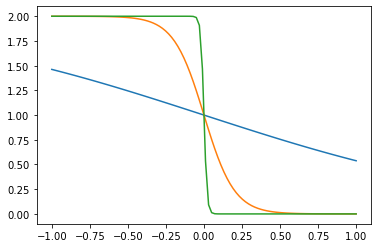

In [6]:
def u(x,nu):
    return 2 / (1 + np.exp(x/nu))

x = np.linspace(-1,1,100)

u1 = u(x,1)
u2 = u(x,0.1)
u3 = u(x,0.01)

fig, ax = plt.subplots()

ax.plot(x, u1)
ax.plot(x, u2)
ax.plot(x, u3)

## 4. Gruntvann

Vi har altså to koblete PDE for $\rho$ og $\vec{u}$.

Hva med $p$? Vi trenger egentlig litt ekstra fra termodynamikk, f eks en tilstandsligning $f(p,\rho,T)=0$ som den perfekte gassloven, eller en ekstra PDE for entropi. Med væsker er det ofte vanlig og anta at den ikke er kompressbar, dvs
$$
\sum_i \frac{\partial u}{\partial x_i} = 0
$$

Det blir fortsett vanskelig! 

En situasjon som er relativt vanlig oppstår når vannet er grunt (i forhold til den horisontale lengdeskale), det kan gunstige forhold antas at $u=u(x)$ er avhengig av kun horisontale retning, og a trykket kommer direkte fra høyden $h(x)$ av vannet over bakken. Under slike forhold får vi et koblet system for $h$ og $u$, som heter **Gruntvannligning**

Her er $v=hu$, hvor $u$ er hastighet, og $h$ er høyden over bakken. Gravitasjonskonstant er $g$.

$$
\begin{pmatrix}
h \\
v
\end{pmatrix}_t
+\begin{pmatrix}
v \\
hv + \frac{1}{2}gh^2
\end{pmatrix}_x
=0
$$


## Oppgave 5: Gruntvannligning


### a) 

Implementer Lax-Friedrichs metode på ligningen over, i et område $a < x <b $. Velg $a$ og $b$, og bruk initialbetingelser

$$
v(0,x)=0,\quad 
h(0,x) = \left\{
\begin{array}[cc]
&100 \quad & x<0 \\
0 \quad & x\geq 0
\end{array}\right.
$$

og randbetingelser $h(t,a)=100$, $h(t,b)=0$.

### b)

Hva ser du? Hva slags fysiske situasjon beskrives her?

### c)

Prøv noen andre initialverdier. Oppstår det sjokk?

## Løsning

### a) 

Se koden under

### b)

Det er et såkelt demning-brudd problem, hvor en stor mengde vann plutselig slippes løs.

### c)

Varierer ut fra hva som er blitt kjørt.

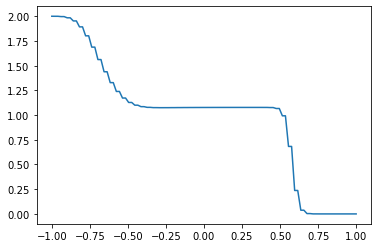

In [7]:
# Må dobbelsjekke koden.

c = 2

def f_u(h,v):
    return v

def f_v(h,v):
    return h*v + 5*(h**2)

def fua(t):
    return 2

def fub(t):
    return 0

def fva(t):
    return 0

def fvb(t):
    return 0

def lf2(fluks_u, fluks_v, ua, ub, va, vb, u0, v0, h, k, t):
    n = u0.size
    u1 = np.zeros(n)
    v1 = np.zeros(n)
    for i in np.arange(1,n-1):
        u1[i] = (u0[i-1] + u0[i+1])/2 - (k/h)*(fluks_u(u0[i+1],v0[i+1])-fluks_u(u0[i-1],v0[i-1]))
        v1[i] = (v0[i-1] + v0[i+1])/2 - (k/h)*(fluks_v(u0[i+1],v0[i+1])-fluks_v(u0[i-1],v0[i-1]))
    u1[0] = ua(t)
    u1[-1] = ub(t)
    v1[0] = va(t)
    v1[-1] = vb(t)
    return u1, v1

T = 20
n = 10000

a = -1
b = 1
m = 100

t = np.linspace(0,T,n)
x = np.linspace(a,b,m)

k = t[1]-t[0]
h = x[1]-x[0]

u = np.zeros((n,m))
v = np.zeros((n,m))

u[0,:] = 1 - np.sign(x)
v[0,:] = 0

for i in np.arange(1,n):
    u[i,:], v[i,:] = lf2(f_u, f_v, fua, fub, fva, fvb, u[i-1,:], v[i-1,:], h,k,t[i])

fig, ax = plt.subplots()

line, = ax.plot(x, u[0,:])

def animate(i):
    line.set_ydata(u[i,:])
    return line,

ani = animation.FuncAnimation(fig, animate, interval=20, blit=True, save_count=50)

from IPython.display import HTML
HTML(ani.to_jshtml())

## Oppgave 6: Optimering (Avsluttende Uke)

Antar at vi høyden på alle punkter $h(0,x)<0$ er mellom 0 og 200.

Antar i tillegg at vi har en rand ved $x=-100$.

### a)

Forklar hvorfor den volum vann mellom $x=-100$ og $x=0$ er

$$
V = \int_{-100}^0 y(x) h(0,x) dx,
$$

Hvor $y(x)$ er bredden av vannet. Anta videre at $y$ er en kjent konstant.

### b)

Hva er er den totale fluks vann over $x=0$ etter tid $T$?

### c)

Bruk Lax-Friedrichs diskretisering til å finne den initial høyde $h(0,x)$ som gir største mulig total fluks vann over $x=0$ etter tid $T=10$, gitt en oppgitt initial volum $V$.

## Løsning

### a) 

Det er bare et vanlig volumintegral

### b) 

Fluks i tid $t$ skal være hastighet $u(t,0)$ ganget med høyden $h(t,0)$ (ganget med konstanten $y$)

Total fluks er altså

$$
\int_0^T y u(t,0) h(t,0) dt
$$

### c) 

Se koden under.

In [27]:
# Fort løsning med bruk av innebygget løser i python

import scipy.optimize as sp

H_max = 4

def fua(t):
    return H_max/2

T = 10
n = 1000

a = -1
b = 1
m = 10

t = np.linspace(0,T,n)
x = np.linspace(a,b,m)

k = t[1]-t[0]
h = x[1]-x[0]

u = np.zeros((n,m))
v = np.zeros((n,m))

#u[0,:] = 1 - np.sign(x), kan brukes som initialverdi
v[0,:] = 0

x0 = 1 - np.sign(x)

A = np.ones((1,m))

con = sp.LinearConstraint(A,lb=0,ub=H_max*np.sum(x0)/2)

# må finne ut hvordan lage en slik list, det er latterlig!

bnds = ((0,H_max),(0,H_max),(0,H_max),(0,H_max), (0,H_max),(0,H_max),(0,H_max),(0,H_max), (0,H_max),(0,H_max))

def f(h0):
    f = 0
    mid = int(m/2) + 1
    u[0,:] = h0
    for i in np.arange(1,n):
        u[i,:], v[i,:] = lf2(f_u, f_v, fua, fub, fva, fvb, u[i-1,:], v[i-1,:], h,k,t[i])
        f = f + u[i,mid]*v[i,mid]
    return -f

res = sp.minimize(f, x0, bounds=bnds, constraints=con)

In [28]:
print(res)

     fun: -2582.1220482024464
     jac: array([ -2.95297241, -11.52902222,  -9.74987793, -13.16784668,
       -10.04129028, -11.94165039,  -7.56863403,  -5.30264282,
        -2.77288818,  -0.78674316])
 message: 'Optimization terminated successfully'
    nfev: 44
     nit: 4
    njev: 4
  status: 0
 success: True
       x: array([1.52429180e-10, 4.00000000e+00, 4.00000000e+00, 4.00000000e+00,
       4.00000000e+00, 4.00000000e+00, 1.23828336e-10, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])


In [29]:
print(res.x)

[1.52429180e-10 4.00000000e+00 4.00000000e+00 4.00000000e+00
 4.00000000e+00 4.00000000e+00 1.23828336e-10 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


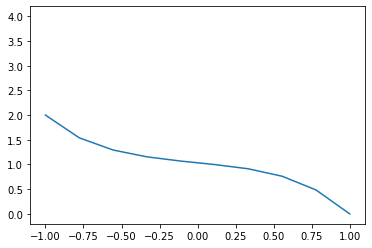

In [30]:
u[0,:] = res.x

for i in np.arange(1,n):
    u[i,:], v[i,:] = lf2(f_u, f_v, fua, fub, fva, fvb, u[i-1,:], v[i-1,:], h,k,t[i])

fig, ax = plt.subplots()

line, = ax.plot(x, u[0,:])

def animate(i):
    line.set_ydata(u[i,:])
    return line,

ani = animation.FuncAnimation(fig, animate, interval=20, blit=True, save_count=50)

from IPython.display import HTML
HTML(ani.to_jshtml())